
Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")
sns.set_style("darkgrid")
sns.set_palette("Set2")

Load Data


In [37]:
file = "Project_RRIS_Gomtinagar.xlsx"

restaurants = pd.read_excel(file, sheet_name=0)
reviews = pd.read_excel(file, sheet_name=1)
competitors = pd.read_excel(file, sheet_name=2)
problems = pd.read_excel(file, sheet_name=3)
restaurants.head()
reviews.head()

,Restaurant_Name,Review_Text,Review_Rating,Review_Time,Sentiment,Issue_Type,Keywords
0,Sky Glass Brewing Co.,Ambience is very awesome 👍,5.0,19 hours ago,Positive,No Issue,"ambience, great ambience"
1,Sky Glass Brewing Co.,Rohit was a nice attender and overall the ambi...,5.0,19 hours ago,Positive,No Issue,"good staff, great ambience, tasty food, good d..."
2,Sky Glass Brewing Co.,I recently visited Sky Bar for dinner with my ...,5.0,a day ago,Positive,No Issue,"great ambience, delicious food, polite staff, ..."
3,Sky Glass Brewing Co.,professnal staff and good vibe.,5.0,2 days ago,Positive,No Issue,"professional staff, good vibe"
4,Sky Glass Brewing Co.,Good hospitality and professional staff,5.0,2 days ago,Positive,No Issue,"good hospitality, professional staff"


Data Understanding

In [38]:
restaurants.info()
reviews.info()
competitors.info()
problems.info()

restaurants.isnull().sum()
reviews.isnull().sum()
competitors.isnull().sum()
problems.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Restaurant_Name      31 non-null     object 
 1   Url                  31 non-null     object 
 2   Location/Area        31 non-null     object 
 3   Address              31 non-null     object 
 4   Rating               31 non-null     float64
 5   Total_Reviews        31 non-null     int64  
 6   Cuisine_Type         31 non-null     object 
 7   Top_5_Selling_items  31 non-null     object 
 8   Price_for_Two        31 non-null     int64  
 9   Platform_Source      31 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant_Name  451 non-null    o

,0
Restaurant_Name,0
Top_Problem_1,0
Top_Problem_2,0
Issue_Count,0
Opportunity_Flag,0
Suggested_Action,0
Expected_Impact,0


Data Cleaning


In [39]:
restaurants.columns = restaurants.columns.str.strip() #Remove extra spaces from column names
reviews.columns = reviews.columns.str.strip()
competitors.columns = competitors.columns.str.strip()
problems.columns = problems.columns.str.strip()
restaurants.drop_duplicates(inplace=True) #Remove duplicate rows
reviews.drop_duplicates(inplace=True)

Create Sentiment Score

In [40]:
sentiment_map = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}

reviews["Sentiment_Score"] = reviews["Sentiment"].map(sentiment_map)

sentiment_score = reviews.groupby("Restaurant_Name")["Sentiment_Score"].mean().reset_index()

restaurants = restaurants.merge(sentiment_score, on="Restaurant_Name", how="left")

Sentiment Distribution

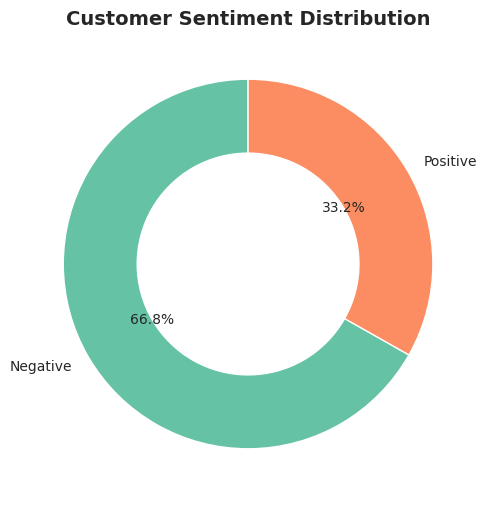

In [41]:
sentiment = reviews['Sentiment'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment,
    labels=sentiment.index,
    autopct="%1.1f%%",
    wedgeprops={'width':0.4},
    startangle=90
)

plt.title("Customer Sentiment Distribution", fontsize=14, fontweight="bold")
plt.show()

Insights
1. 66.8% reviews are negative showing low customer satisfaction.
2. Immediate improvements in food quality and services are required.
3. Negative sentiment can impact ratings and repeat customers.
4. Strong customer support can improve brand image.

Operational Issue Heatmap Across Top Restaurants

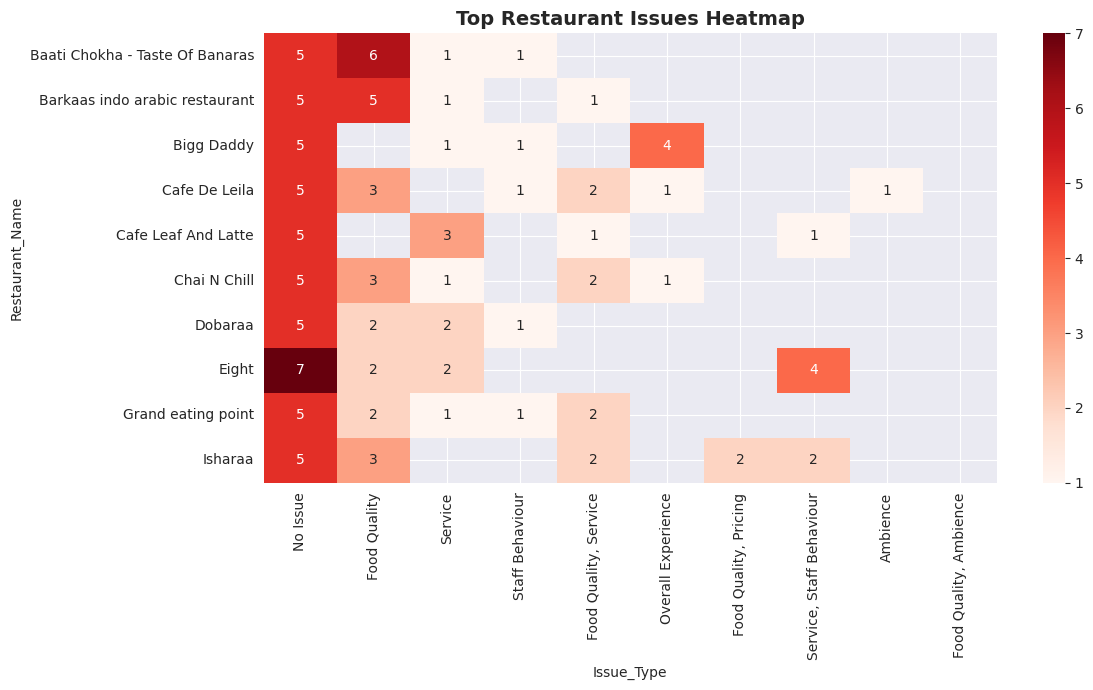

In [42]:
issue_pivot = reviews.pivot_table(
    index="Restaurant_Name",
    columns="Issue_Type",
    aggfunc="size",
    fill_value=0
)

# top 10 issues
top_issues = issue_pivot.sum().sort_values(ascending=False).head(10).index

# top 10 restaurants
top_restaurants = issue_pivot.sum(axis=1).sort_values(ascending=False).head(10).index

issue_pivot_top = issue_pivot.loc[top_restaurants, top_issues]

plt.figure(figsize=(12,7))

sns.heatmap(
    issue_pivot_top,
    cmap="Reds",
    mask=issue_pivot_top==0,
    annot=True,
    fmt="d"
)

plt.title("Top Restaurant Issues Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Insights
1. Food quality is the most common issue across restaurants.
2. Service complaints are also frequent and need improvement.
3. Restaurant Eight shows the highest issue concentration.
4. A few restaurants generate most complaints.
5. Targeted corrective action can improve overall customer satisfaction.

Recommendations
1. conduct food quality audits regularly.
2. Improve service speed and staff training.
3. Focus first on high -issue restaurants.
4. Track repeated complaints monthly.
5. Replicate best practices from low-issue restaurants.

Competitor Analysis

/tmp/ipykernel_5118/695364626.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


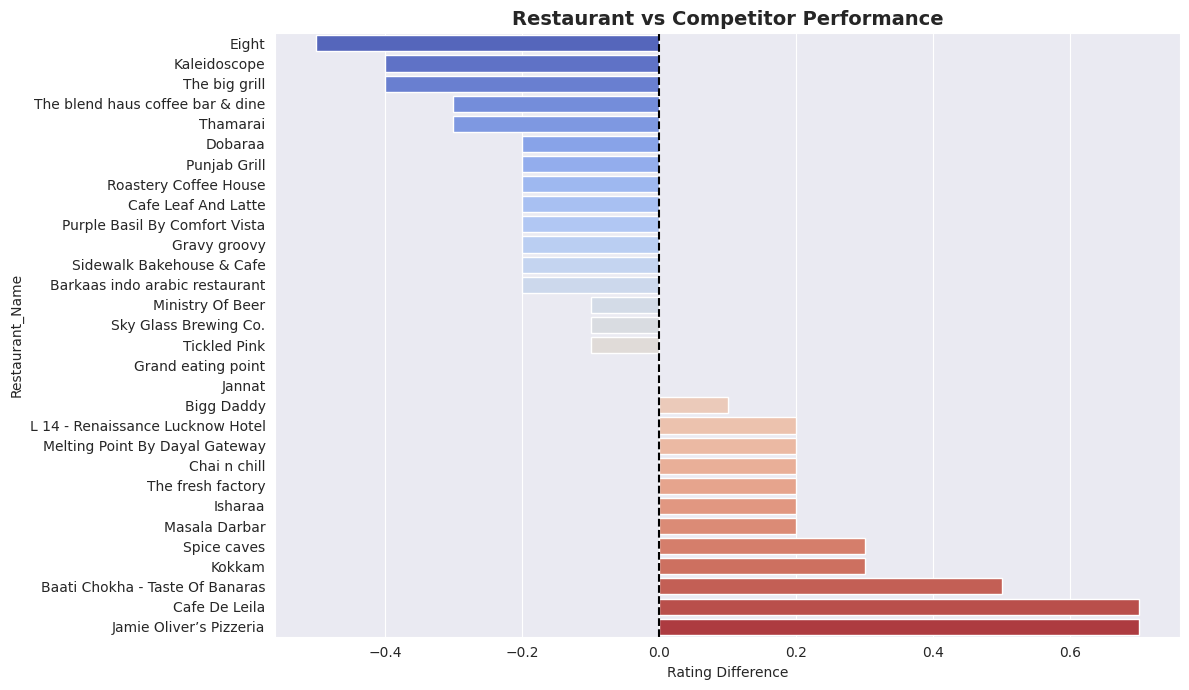

In [43]:
plt.figure(figsize=(12,7))

competitors_sorted = competitors.sort_values("Rating_Difference")

sns.barplot(
    data=competitors_sorted,
    x="Rating_Difference",
    y="Restaurant_Name",
    palette="coolwarm"
)

plt.axvline(0, color="black", linestyle="--")

plt.title("Restaurant vs Competitor Performance", fontsize=14, fontweight="bold")
plt.xlabel("Rating Difference")

plt.tight_layout()
plt.show()

Insights
1. Some restaurants outperform competitors,while others lag behind.
2. Negative rating difference indicates competitor advantage.
3. Positive rating difference reflects better customer satisfaction.
4. Restaurants near zero are highly competitive and need small improvements.
5. Focus on low-performing restaurants to improve market position.

Recommendations
1. Improve food quality and service where rating difference is nagative.
2. Study top-performing restaurants as benchmarks.
3. Promote restaurants with positive rating advantage.
4. Monitor competitors regularly.
5. Use customer  feedback to close rating gaps.

Negative Review Analysis

/tmp/ipykernel_5118/3724342710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


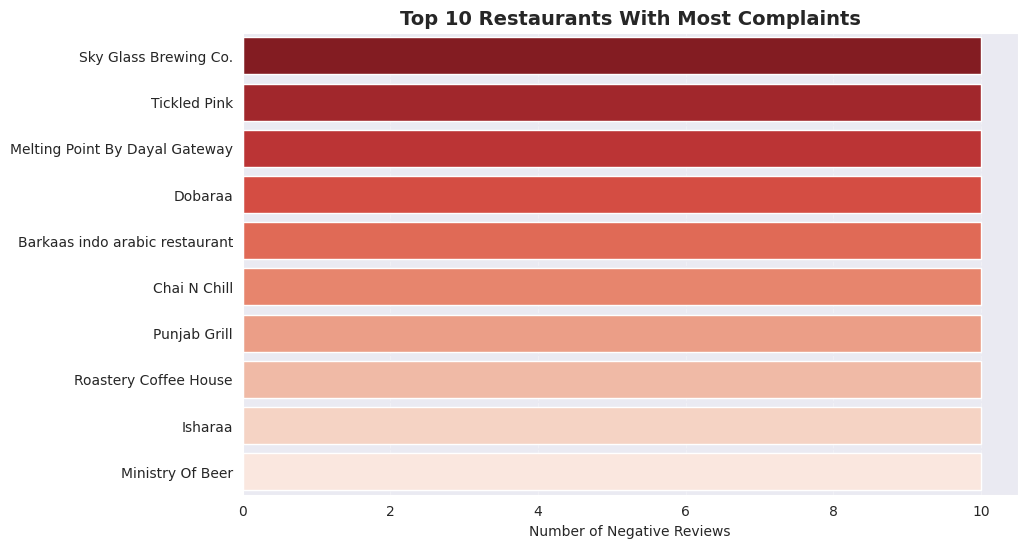

In [44]:
negative = reviews[reviews["Sentiment"] == "Negative"]

negative_count = negative["Restaurant_Name"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=negative_count.values,
    y=negative_count.index,
    palette="Reds_r"
)

plt.title("Top 10 Restaurants With Most Complaints", fontsize=14, weight="bold")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

Insights
1. Negative reviews are concentracted in a few restaurants.
2. Sky Glass Brewing Co. shows the highest complaint volume.
3. Top complaint restaurants need urgent quality and service improvements.
4. Repeated complaints may reduce ratings and customer loyalty.
5. Targeted corrective action can improve brand reputation quickly.

Recommendations
1. Priortize the top 5 complaint restaurants first.
2. Improve food quality,speed, and customer handling.
3. Resopnd quickly to online negative reviews.
4. Track complaints weekly to identify recuring issues.
5. Use customer feedback to redesign weak processes.

Rating vs Issues

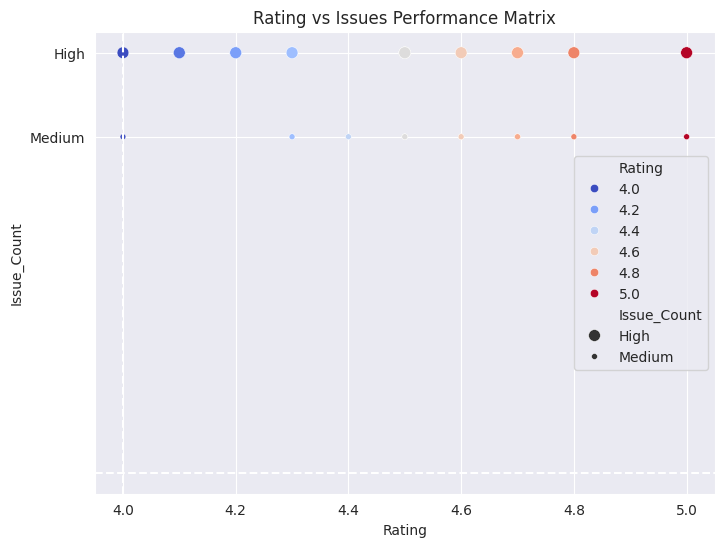

In [45]:
df = restaurants.merge(problems, on="Restaurant_Name")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Issue_Count",
    size="Issue_Count",
    hue="Rating",
    palette="coolwarm"
)

plt.axvline(4, linestyle="--")
plt.axhline(5, linestyle="--")

plt.title("Rating vs Issues Performance Matrix")
plt.show()

Insights
1. Low rating and high issue count restaurants are high-risk performers.
2. High rating with low issues represents strong performers.
3. Issue count appers to negatively affect ratings.
4. Mid-performing restaurants have quick improvement potential.
5. Reducing issues can improve ratings and reputaion.

Recommendations
1. Priortize restaurants with low ratings and high issues.
2. Replicate best practices from stron performers.
3. Reduce recurring complaints through process improvement.
4. Monitor ratings and issues monthly.
5. Reward consistently high-performing restaurants.

/tmp/ipykernel_5118/4281104917.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


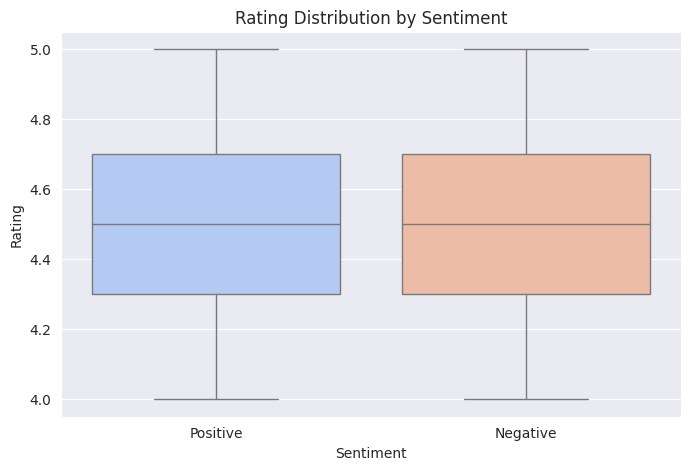

In [46]:
plt.figure(figsize=(8,5))

merged = reviews.merge(
    restaurants[["Restaurant_Name","Rating"]],
    on="Restaurant_Name"
)

sns.boxplot(
    data=merged,
    x="Sentiment",
    y="Rating",
    palette="coolwarm"
)

plt.title("Rating Distribution by Sentiment")
plt.show()


Insights:


*   Positive sentiment corresponds to higher ratings.
*   Negative sentiment reviews cluster at lower ratings.
*   Improving customer experience will increase rating.









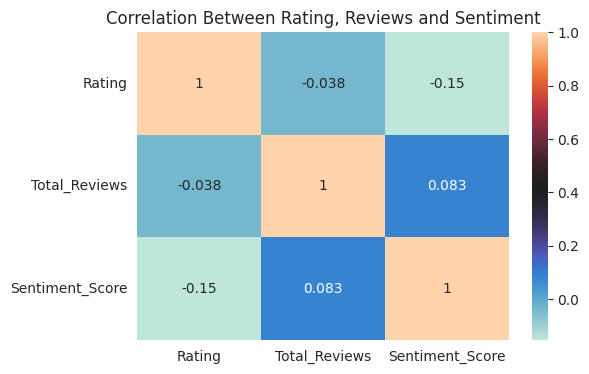

In [47]:
plt.figure(figsize=(6,4))

sns.heatmap(
    restaurants[["Rating","Total_Reviews","Sentiment_Score"]].corr(),
    annot=True,
    cmap="icefire"
)

plt.title("Correlation Between Rating, Reviews and Sentiment")
plt.show()


Insights:


*   Higher sentiment score is associated with higher ratings.
*   More reviews indicate popularity.
*   Strong correlation suggests sentiment impacts rating.









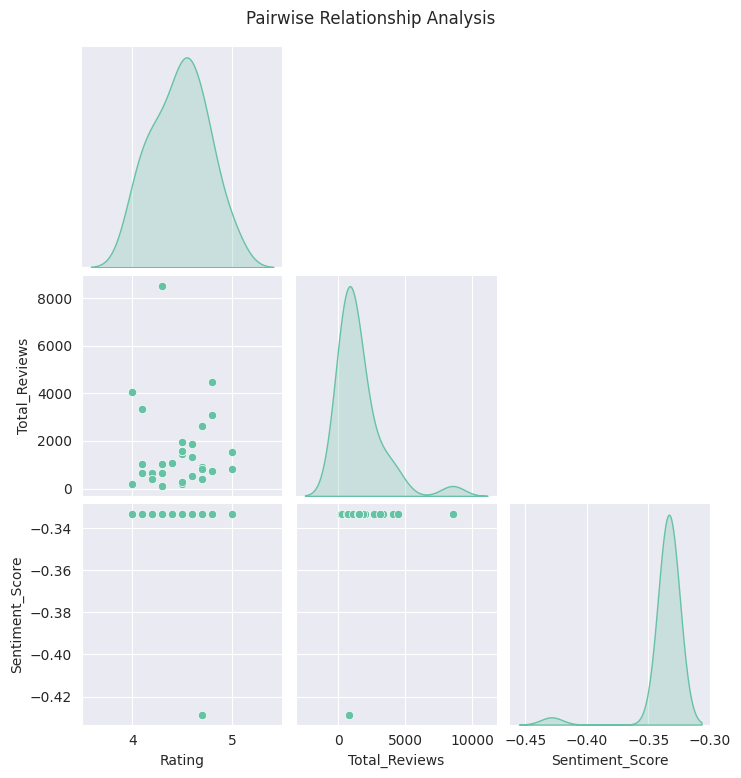

In [48]:
g = sns.pairplot(
    restaurants[["Rating","Total_Reviews","Sentiment_Score"]],
    diag_kind="kde",
    corner=True
)

g.fig.suptitle("Pairwise Relationship Analysis", y=1.03)
plt.show()


Insights:


*  Pairplot shows relationships between rating, reviews and sentiment.
*  Restaurants with better sentiment tend to have higher ratings.
*  Popularity and rating relationship helps identify top performers.









/tmp/ipykernel_5118/1670909430.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5118/1670909430.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5118/1670909430.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_5118/1670909430.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


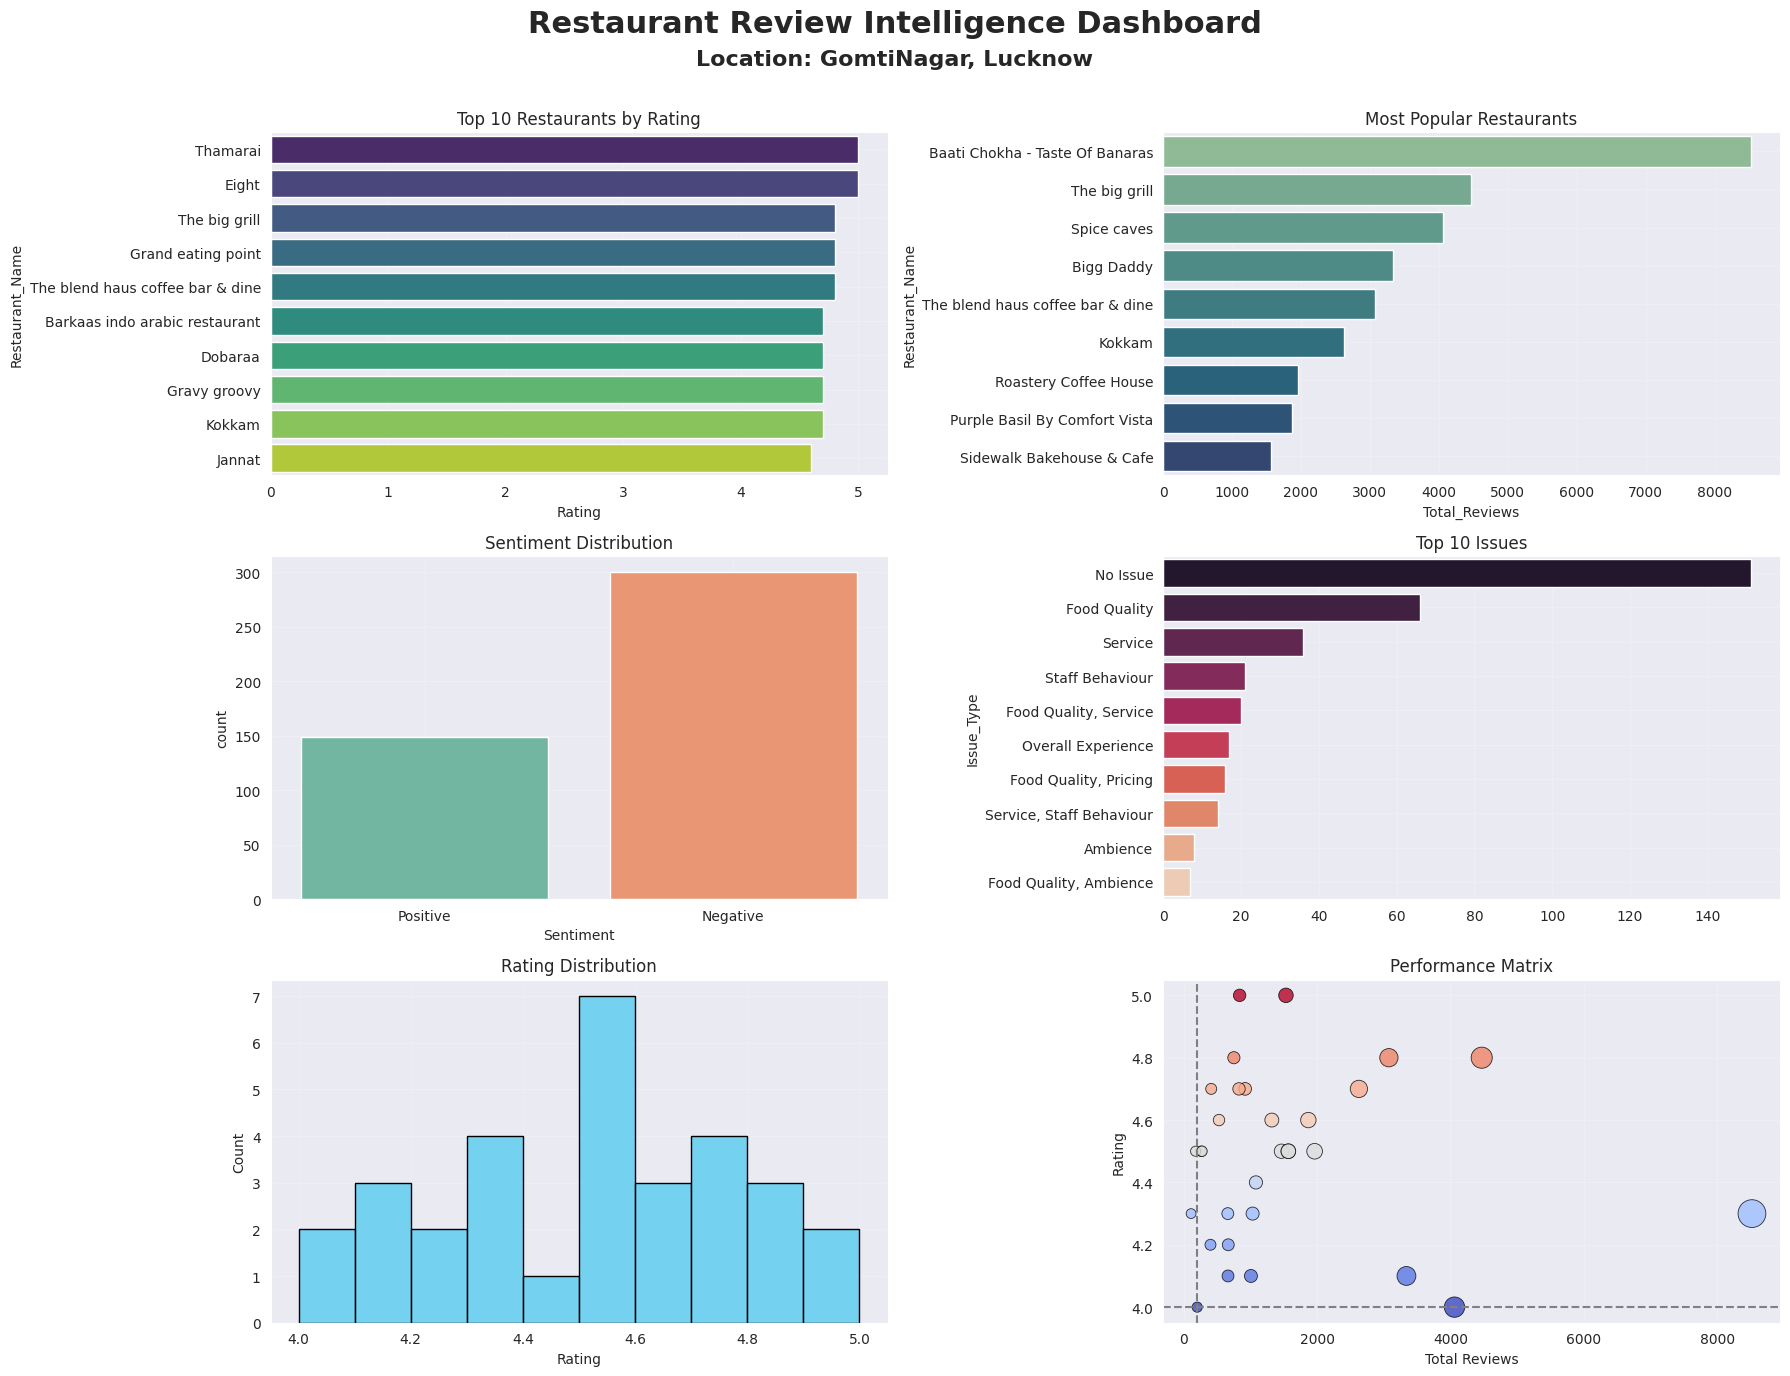

In [49]:
fig, axes = plt.subplots(3,2, figsize=(18,14))


fig.suptitle(
    "Restaurant Review Intelligence Dashboard",
    fontsize=22,
    fontweight="bold"

)
fig.text(0.5, 0.94, "Location: GomtiNagar, Lucknow", ha="center", fontsize=16,fontweight="bold" )
# Top Rated
top10 = restaurants.sort_values("Rating", ascending=False).head(10)

sns.barplot(
    data=top10,
    y="Restaurant_Name",
    x="Rating",
    ax=axes[0,0],
    palette="viridis"
)

axes[0,0].set_title("Top 10 Restaurants by Rating")


# Most Popular
popular = restaurants.sort_values("Total_Reviews", ascending=False).head(10)

sns.barplot(
    data=popular,
    y="Restaurant_Name",
    x="Total_Reviews",
    ax=axes[0,1],
    palette="crest"
)

axes[0,1].set_title("Most Popular Restaurants")


# Sentiment
sns.countplot(
    data=reviews,
    x="Sentiment",
    ax=axes[1,0],
    palette="Set2"
)

axes[1,0].set_title("Sentiment Distribution")


# Top Issues
top_issues = reviews["Issue_Type"].value_counts().head(10)

sns.barplot(
    x=top_issues.values,
    y=top_issues.index,
    ax=axes[1,1],
    palette="rocket"
)

axes[1,1].set_title("Top 10 Issues")


# Rating Distribution
sns.histplot(
    restaurants["Rating"],
    bins=10,
    ax=axes[2,0],
    color="#4cc9f0",
    edgecolor="black"
)

axes[2,0].set_title("Rating Distribution")


# Performance Matrix
sns.scatterplot(
    data=restaurants,
    x="Total_Reviews",
    y="Rating",
    size="Total_Reviews",
    hue="Rating",
    sizes=(50, 400),
    palette="coolwarm",
    alpha=0.8,
    edgecolor="black",
    legend=False,
    ax=axes[2,1]
)
axes[2,1].axhline(4.0, linestyle="--", color="gray")
axes[2,1].axvline(200, linestyle="--", color="gray")

axes[2,1].set_title("Performance Matrix")
axes[2,1].set_xlabel("Total Reviews")
axes[2,1].set_ylabel("Rating")

for ax in axes.flat:
    ax.grid(alpha=0.2)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()



Insights
1. Most restaurants have good ratings(4.3-4.8),showing strong customer satisfaction.
2. Some restaurants are popular but average rated,so popularity does not equal to quality.
3. Main complaints are Food Quality,Service,staff Behaviour.
4. Negative reviews are higher than positive,showing improvement scope.
5. Restaurants with high reviews + high ratings are market leaders.    

Recommendations
1. Improve food quality and hygiene.
2. Reduce service dalay and improve speed.
3. Train staff for better behaviour.
4. Focus on popular but low-rated restaurants.
5. Track customer feedback regularly.